In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'D:\Data Analytics\DA_python_projects\netflix_analysis\dataset\clean_dataset.csv' )
df.head(5)

,show_id,category,title,director,cast,country,date_added,rating,duration,genres,year_added,month_added,duration_value,duration_unit,duration_min,seasons,primary_country,primary_genre
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",2020,8,4,Seasons,NaN,4.0,Brazil,International TV Shows
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,TV-MA,93 min,"Dramas, International Movies",2016,12,93,min,93.0,NaN,Mexico,Dramas
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,R,78 min,"Horror Movies, International Movies",2018,12,78,min,78.0,NaN,Singapore,Horror Movies
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...",2017,11,80,min,80.0,NaN,United States,Action & Adventure
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,PG-13,123 min,Dramas,2020,1,123,min,123.0,NaN,United States,Dramas


In [3]:
df.describe()

,year_added,month_added,duration_value,duration_min,seasons
count,7777.000000,7777.000000,7777.000000,5377.000000,2400.000000
mean,2018.493378,6.783850,69.204706,99.307978,1.760833
std,1.388144,3.591608,50.931983,28.530881,1.560603
min,2008.000000,1.000000,1.000000,3.000000,1.000000
25%,2018.000000,4.000000,2.000000,86.000000,1.000000
50%,2019.000000,7.000000,88.000000,98.000000,1.000000
75%,2020.000000,10.000000,106.000000,114.000000,2.000000
max,2021.000000,12.000000,312.000000,312.000000,16.000000


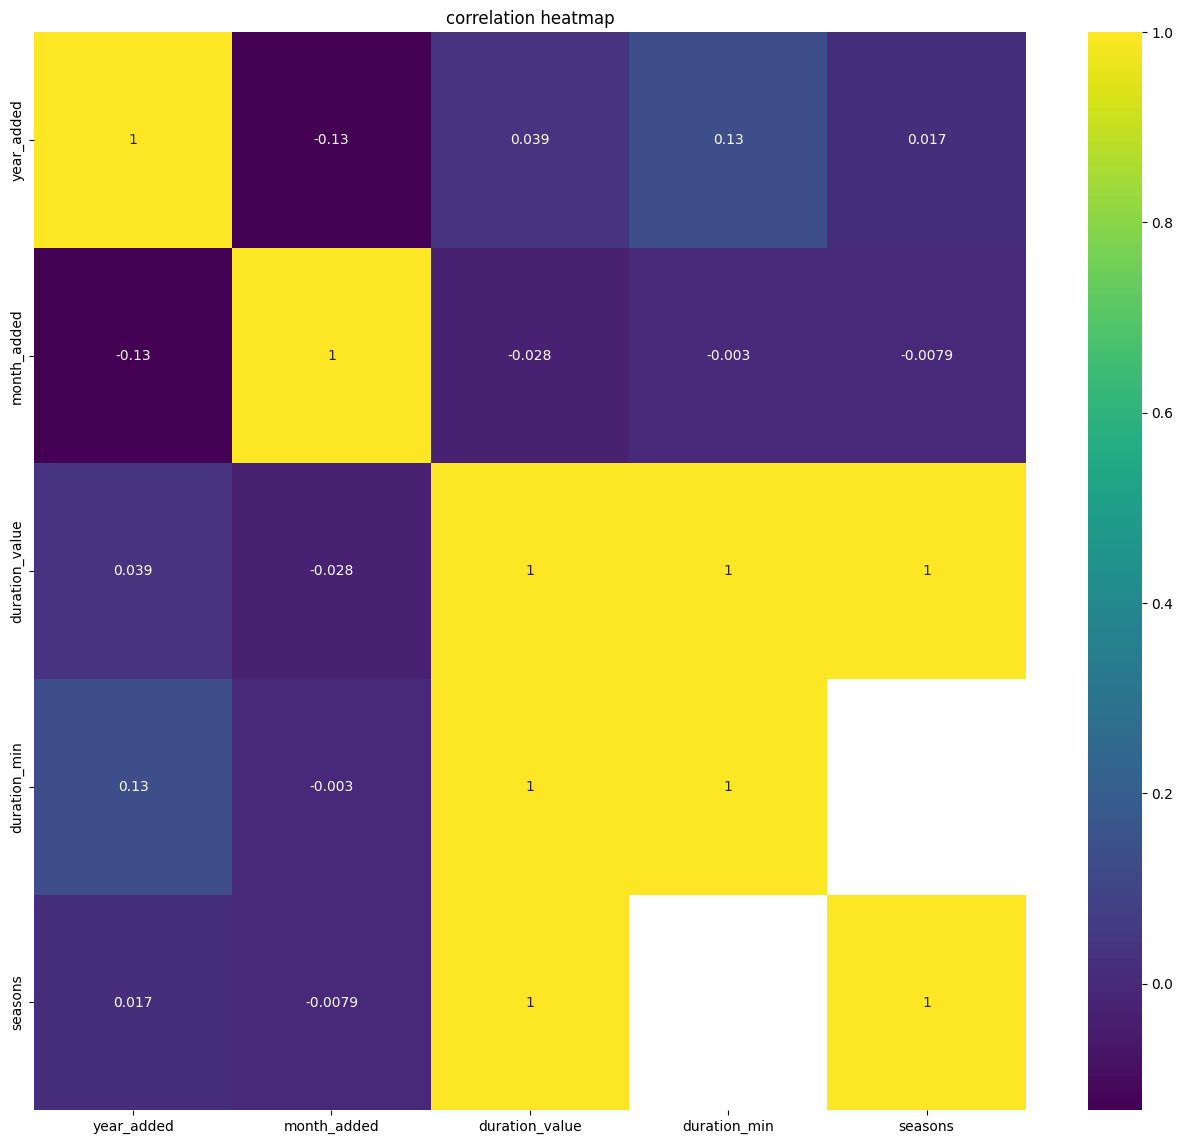

In [6]:
drop_col = df.drop(columns=['show_id'])
numeric_cols = drop_col.select_dtypes(include=['int64','float32','int32','float64'])
plt.figure(figsize=(16,14))
sns.heatmap(numeric_cols.corr() , annot=True ,cmap="viridis" )
plt.title("correlation heatmap")
plt.show()

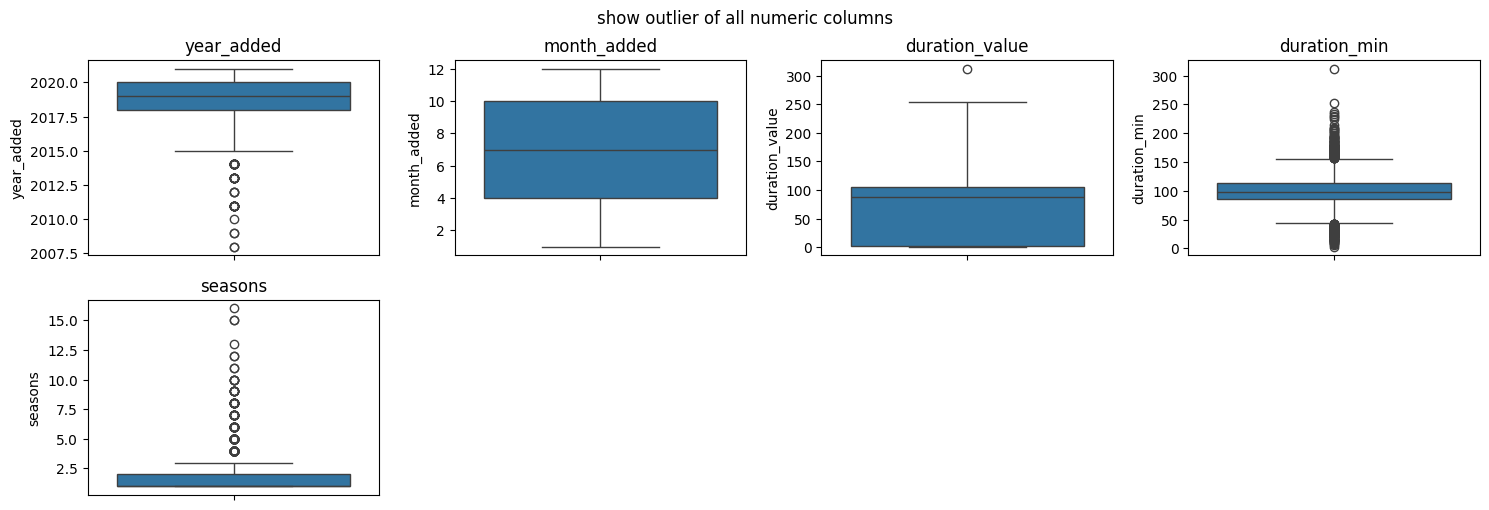

In [7]:
# numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 4, i + 1) # adjust the number of rows and columns as needed
    sns.boxplot(df[col])
    plt.title(col)
plt.suptitle('show outlier of all numeric columns')
plt.tight_layout()
plt.show()

In [9]:
# how many outlier in column??
def detect_outliers(df , col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_iqr = ((df[col] < lower_bound) | (df[col] > upper_bound))
    print(f"IQR method identified {outliers_iqr.sum()} outliers in {col}")
    return outliers_iqr

outlier_col = ['year_added' , 'month_added' , 'duration_value' , 'duration_min' , 'seasons']

for col in outlier_col:
    detect_outliers(df ,col)

IQR method identified 57 outliers in year_added
IQR method identified 0 outliers in month_added
IQR method identified 1 outliers in duration_value
IQR method identified 337 outliers in duration_min
IQR method identified 231 outliers in seasons


# 📊KPI

In [16]:
total_genere = df['primary_genre'].nunique()
print(f'total genere avalilable {total_genere}')

avg_duration = df['duration_min'].mean()
print(f'avg duration min {avg_duration.round(2)} min')

total_movies = (df["category"] == "Movie").sum()
print(f"Total Movies: {total_movies:,}")

total_tv_shows = (df["category"] == "TV Show").sum()
print(f"Total Movies: {total_tv_shows:,}")

total genere avalilable 36
avg duration min 99.31 min
Total Movies: 5,377
Total Movies: 2,400


# 📊analysis